# Assignment 1: Soft-margin SVM using NumPy on Chest X-Ray Pneumonia Dataset

Trong bài thực hành này, mô hình Soft-margin Support Vector Machine được cài đặt bằng NumPy và huấn luyện bằng phương pháp Stochastic Gradient Descent. Bộ dữ liệu được sử dụng là Chest X-Ray Images (Pneumonia), gồm hai lớp ảnh: NORMAL và PNEUMONIA.

Notebook này đóng vai trò là file thực nghiệm chính. Các bước chính bao gồm xác định đường dẫn dữ liệu, kiểm tra số lượng ảnh, đọc ảnh, resize ảnh về 128 × 128, chuẩn hóa dữ liệu, huấn luyện mô hình SVM và đánh giá mô hình bằng Precision, Recall và F1-score.

## 1. Xác định đường dẫn dữ liệu

Sau khi tải dataset từ Kaggle, thư mục dữ liệu có hai cấp `chest_xray`. Khi kiểm tra số lượng ảnh, thư mục `C:\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray` cho số lượng ảnh khớp với phần mô tả của Kaggle. Vì vậy, thư mục này được chọn làm `BASE_DIR` chính cho bài thực hành.

In [7]:
import os
from data_utils import count_images, collect_data

BASE_DIR = r"C:\Users\Admin\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray"

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("Train exists:", os.path.exists(os.path.join(BASE_DIR, "train")))
print("Validation exists:", os.path.exists(os.path.join(BASE_DIR, "val")))
print("Test exists:", os.path.exists(os.path.join(BASE_DIR, "test")))

BASE_DIR exists: True
Train exists: True
Validation exists: True
Test exists: True


## 2. Kiểm tra số lượng tập tin hình ảnh trong từng tập dữ liệu


In [8]:
train_counts = count_images(BASE_DIR, "train")
val_counts = count_images(BASE_DIR, "val")
test_counts = count_images(BASE_DIR, "test")

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

total_images = sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())
print("Total images:", total_images)

Train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Validation: {'NORMAL': 8, 'PNEUMONIA': 8}
Test: {'NORMAL': 234, 'PNEUMONIA': 390}
Total images: 5856


### Nhận xét

Dữ liệu gồm hai lớp: NORMAL và PNEUMONIA. Thông thường, số lượng ảnh PNEUMONIA nhiều hơn số lượng ảnh NORMAL, đặc biệt trong tập train. Điều này cho thấy dataset có hiện tượng mất cân bằng lớp. Vì vậy, các chỉ số Precision, Recall và F1-score phù hợp hơn so với việc chỉ quan sát Accuracy.

## 3. Đọc ảnh và tiền xử lý dữ liệu

Mô hình SVM tuyến tính không làm việc trực tiếp với ảnh hai chiều mà làm việc với vector đặc trưng. Vì vậy, mỗi ảnh X-ray cần được chuyển đổi thành một vector số.

Trong bước này, ảnh được đọc bằng OpenCV, chuyển sang ảnh grayscale, resize về kích thước 128 × 128 theo yêu cầu của assignment, sau đó flatten thành vector một chiều. Giá trị pixel ban đầu nằm trong khoảng từ 0 đến 255, nên dữ liệu được chuẩn hóa về khoảng [0, 1] bằng cách chia cho 255.

In [3]:
import cv2 as cv
import numpy as np
import os
from tqdm import tqdm

def collect_data(split: str = "train"):
    NORMAL_LABEL = 1
    PNEUMONIA_LABEL = -1

    images = []
    labels = []

    normal_path = os.path.join(BASE_DIR, split, "NORMAL")

    for img_file in tqdm(os.listdir(normal_path), desc=f"Loading {split} - NORMAL"):
        img_path = os.path.join(normal_path, img_file)
        img = cv.imread(img_path)

        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (128, 128), interpolation=cv.INTER_LINEAR)
            img = img.reshape(-1)
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(NORMAL_LABEL)

    pneumonia_path = os.path.join(BASE_DIR, split, "PNEUMONIA")

    for img_file in tqdm(os.listdir(pneumonia_path), desc=f"Loading {split} - PNEUMONIA"):
        img_path = os.path.join(pneumonia_path, img_file)
        img = cv.imread(img_path)

        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (128, 128), interpolation=cv.INTER_LINEAR)
            img = img.reshape(-1)
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(PNEUMONIA_LABEL)

    return np.stack(images, axis=0), np.array(labels)

## 4. Tạo tập train, validation và test

Sau khi định nghĩa hàm đọc dữ liệu, ta tiến hành đọc ba tập train, validation và test. Tập train được dùng để huấn luyện mô hình. Tập validation được dùng để kiểm tra sơ bộ hiệu năng mô hình trong quá trình thử nghiệm. Tập test được giữ riêng để đánh giá cuối cùng.

Sau khi resize về 128 × 128 và flatten, mỗi ảnh trở thành một vector có 16.384 chiều.

In [3]:
X_train, y_train = collect_data(BASE_DIR, "train")
X_val, y_val = collect_data(BASE_DIR, "val")
X_test, y_test = collect_data(BASE_DIR, "test")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading test - PNEUMONIA:  89%|████████▉ | 347/390 [00:06<00:00, 55.86it/s]


KeyboardInterrupt: 

### Nhận xét

Sau bước tiền xử lý, dữ liệu đã có dạng phù hợp để đưa vào mô hình SVM tuyến tính. Mỗi ảnh đều có cùng kích thước, cùng số chiều đặc trưng và cùng miền giá trị pixel.

Với kích thước 128 × 128, mỗi ảnh được biểu diễn bằng vector có 16.384 chiều. Đây là không gian đặc trưng khá lớn, nhưng vẫn phù hợp với yêu cầu bài thực hành vì mục tiêu chính là cài đặt Soft-margin SVM bằng NumPy.

## 5. Hiển thị một số ảnh mẫu

Trước khi huấn luyện, ta hiển thị một số ảnh mẫu để kiểm tra dữ liệu sau khi đọc và tiền xử lý. Vì ảnh đã được flatten thành vector một chiều, cần reshape vector về dạng 128 × 128 trước khi hiển thị.

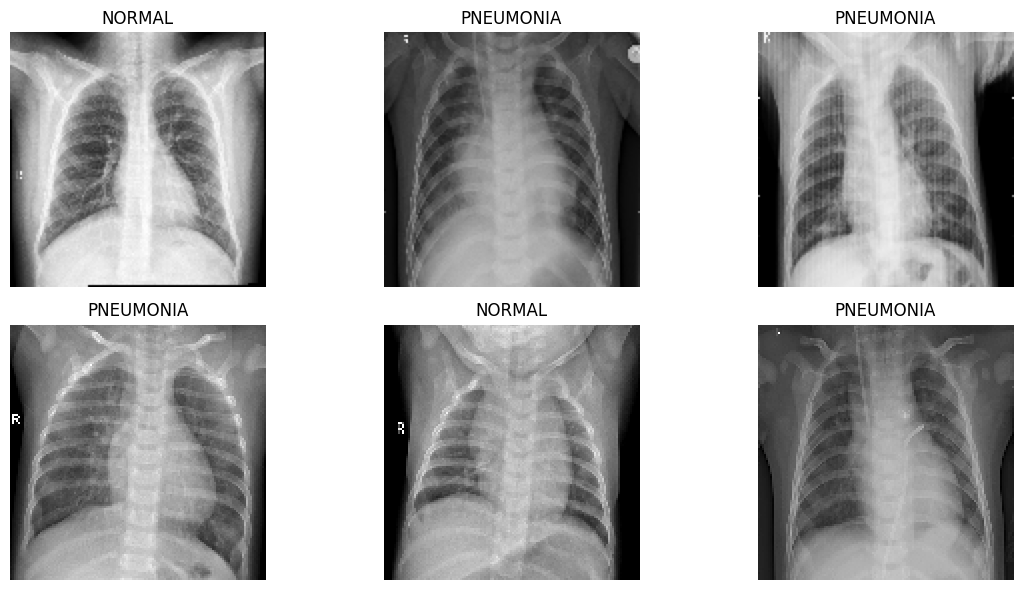

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(X, y, n_samples=6):
    indices = np.random.choice(len(X), size=n_samples, replace=False)

    plt.figure(figsize=(12, 6))

    for i, idx in enumerate(indices):
        image = X[idx].reshape(128, 128)
        label = "NORMAL" if y[idx] == 1 else "PNEUMONIA"

        plt.subplot(2, 3, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(X_train, y_train)

## 6. Import mô hình SVM

Phần cài đặt thuật toán SVM được đặt trong file `svm.py`. Notebook này chỉ import class `SVM` để thực hiện quá trình huấn luyện và đánh giá.

File `svm.py` thể hiện phần tự cài đặt thuật toán, còn `main.ipynb` thể hiện quy trình thực nghiệm trên dataset.

In [6]:
from SVM import SoftMarginSVM

## 7. Huấn luyện mô hình Soft-margin SVM

Mô hình được huấn luyện bằng Stochastic Gradient Descent. Với mỗi mẫu dữ liệu, mô hình tính giá trị \(w^Tx + b\), sau đó kiểm tra điều kiện margin.

Nếu \(y_i(w^Tx_i + b) \geq 1\), mẫu được phân loại đúng và nằm ngoài margin. Khi đó, cập nhật trọng số chủ yếu đến từ regularization. Nếu \(y_i(w^Tx_i + b) < 1\), mẫu bị phân loại sai hoặc nằm trong margin, khi đó mô hình cập nhật theo cả regularization và hinge loss.

Các siêu tham số chính gồm learning rate, số epoch và tham số C. Tham số C điều chỉnh mức độ phạt đối với các mẫu vi phạm margin.

In [16]:
svm_model = SoftMarginSVM(
    lr=0.0001,
    epochs=200,
    C=1.0,
    random_state=42
)

svm_model.fit(X_train, y_train)

Epoch 1/200, Loss: 1101.3589
Epoch 2/200, Loss: 934.0519
Epoch 3/200, Loss: 1364.9574
Epoch 4/200, Loss: 858.4101
Epoch 5/200, Loss: 1011.7350
Epoch 6/200, Loss: 856.8008
Epoch 7/200, Loss: 858.7548
Epoch 8/200, Loss: 1226.3309
Epoch 9/200, Loss: 1925.6087
Epoch 10/200, Loss: 851.8625
Epoch 11/200, Loss: 1073.6784
Epoch 12/200, Loss: 874.6921
Epoch 13/200, Loss: 953.7204
Epoch 14/200, Loss: 845.0728
Epoch 15/200, Loss: 851.3283
Epoch 16/200, Loss: 847.1302
Epoch 17/200, Loss: 915.0141
Epoch 18/200, Loss: 909.0620
Epoch 19/200, Loss: 835.2178
Epoch 20/200, Loss: 1943.3345
Epoch 21/200, Loss: 1376.7803
Epoch 22/200, Loss: 1056.8304
Epoch 23/200, Loss: 1023.1077
Epoch 24/200, Loss: 1301.2982
Epoch 25/200, Loss: 1035.4019
Epoch 26/200, Loss: 999.6406
Epoch 27/200, Loss: 846.4837
Epoch 28/200, Loss: 1463.5066
Epoch 29/200, Loss: 961.5871
Epoch 30/200, Loss: 834.8970
Epoch 31/200, Loss: 1342.9666
Epoch 32/200, Loss: 1066.5745
Epoch 33/200, Loss: 842.6271
Epoch 34/200, Loss: 966.9325
Epoch 35

## 8. Vẽ đồ thị loss theo epoch

Đồ thị loss giúp quan sát trực quan quá trình tối ưu của mô hình. Nếu loss giảm dần, quá trình học đang diễn ra hợp lý. Nếu loss dao động mạnh, learning rate có thể quá lớn. Nếu loss gần như không thay đổi, learning rate có thể quá nhỏ hoặc số epoch chưa đủ.

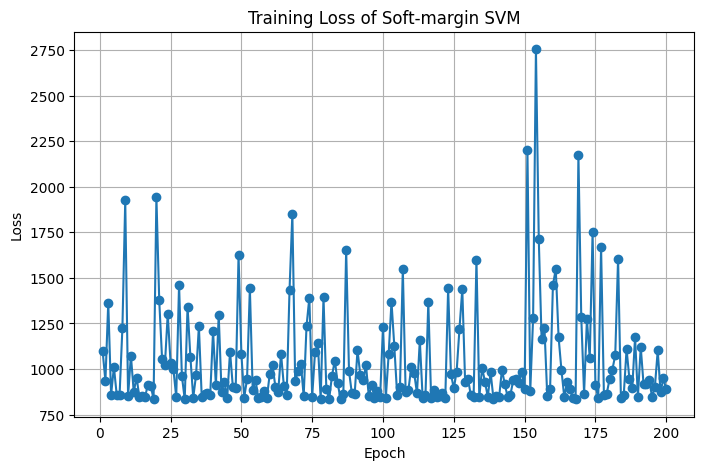

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(svm_model.losses) + 1), svm_model.losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss of Soft-margin SVM")
plt.grid(True)
plt.show()

## 9. Đánh giá mô hình trên tập test

Tập test được dùng để đánh giá cuối cùng vì đây là tập dữ liệu không được sử dụng trong quá trình huấn luyện. Kết quả trên tập test phản ánh tốt hơn khả năng tổng quát hóa của mô hình.

Trong bài toán này, PNEUMONIA là lớp cần quan tâm hơn vì mục tiêu là phát hiện ảnh X-ray có dấu hiệu viêm phổi.

In [24]:
implemented_svm_test_metrics = svm_model.get_metrics(
    X_test,
    y_test,
    positive_label=-1
)

print("Test metrics of Implemented SVM")

for metric_name, metric_value in implemented_svm_test_metrics.items():
    print(f"{metric_name}: {metric_value}")

Test metrics of Implemented SVM
TP: 386
FP: 169
FN: 4
TN: 65
Accuracy: 0.7227564102448276
Precision: 0.6954954954829641
Recall: 0.9897435897182116
F1: 0.8169312120663589


## 10. Tạo confusion matrix

Confusion matrix giúp phân tích chi tiết số lượng dự đoán đúng và sai của mô hình. Với quy ước nhãn NORMAL = 1 và PNEUMONIA = -1, ta sắp xếp confusion matrix theo thứ tự nhãn `[1, -1]`.

Theo thứ tự này, ma trận được hiểu là:

\[
\begin{bmatrix}
NORMAL \rightarrow NORMAL & NORMAL \rightarrow PNEUMONIA \\
PNEUMONIA \rightarrow NORMAL & PNEUMONIA \rightarrow PNEUMONIA
\end{bmatrix}
\]

Ô phía dưới bên trái là số ảnh PNEUMONIA bị dự đoán nhầm thành NORMAL. Đây là nhóm lỗi cần chú ý vì nó tương ứng với False Negative nếu PNEUMONIA là positive class.

In [25]:
import numpy as np

def confusion_matrix_binary(y_true, y_pred):
    normal_to_normal = np.sum((y_true == 1) & (y_pred == 1))
    normal_to_pneumonia = np.sum((y_true == 1) & (y_pred == -1))
    pneumonia_to_normal = np.sum((y_true == -1) & (y_pred == 1))
    pneumonia_to_pneumonia = np.sum((y_true == -1) & (y_pred == -1))

    return np.array([
        [normal_to_normal, normal_to_pneumonia],
        [pneumonia_to_normal, pneumonia_to_pneumonia]
    ])

y_test_pred_implemented = svm_model.predict(X_test)

implemented_svm_confusion_matrix = confusion_matrix_binary(
    y_test,
    y_test_pred_implemented
)

print(implemented_svm_confusion_matrix)

[[ 65 169]
 [  4 386]]


### Nhận xét từ confusion matrix

Confusion matrix cho thấy mô hình dự đoán đúng và sai như thế nào trên từng lớp. Nếu ô `PNEUMONIA → NORMAL` có giá trị lớn, mô hình đang bỏ sót nhiều trường hợp PNEUMONIA. Đây là lỗi cần quan tâm trong bài toán y khoa.

Nếu ô `NORMAL → PNEUMONIA` có giá trị lớn, mô hình đang cảnh báo nhầm nhiều ảnh NORMAL thành PNEUMONIA. Loại lỗi này cũng ảnh hưởng đến độ chính xác của mô hình, nhưng trong bối cảnh phát hiện bệnh, nó thường ít nghiêm trọng hơn lỗi bỏ sót PNEUMONIA.